<a href="https://colab.research.google.com/github/juleuzun/Python_DataScience_Bootcamp/blob/main/Lessons/Lesson_06_regression_and_classification_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = 2 * np.random.rand(100,1)

In [2]:
y = 4 + 3 * X + np.random.randn(100,1)   # Adds random Gaussian noise

In [3]:
X_b = np.c_[np.ones((100,1)),X] # Adding bias values

# Hyperparameters

In [4]:
learning_rate = 0.1
n_iterations = 1000
n_samples = 100

# Initialization of Weights

In [5]:
weights = np.random.randn(2,1)

In [6]:
for iteration in range (n_iterations):
  gradients = 2/n_samples * X_b.T.dot(X_b.dot(weights) - y) # Compute the gradient using the derivative of MSE
  weights -=learning_rate * gradients # Update weights (Gradient descent step)

In [7]:
# Define the cost (loss) function
def compute_cost(X, y, weights):
  m = len(y) # Number of samples in the dataset
  predictions = X.dot(weights) # Predicted values by the model
  cost = np.sum((predictions - y)**2) / (2 * m) # Calculate the Mean Squared Error (MSE)
  return cost # Return the cost value

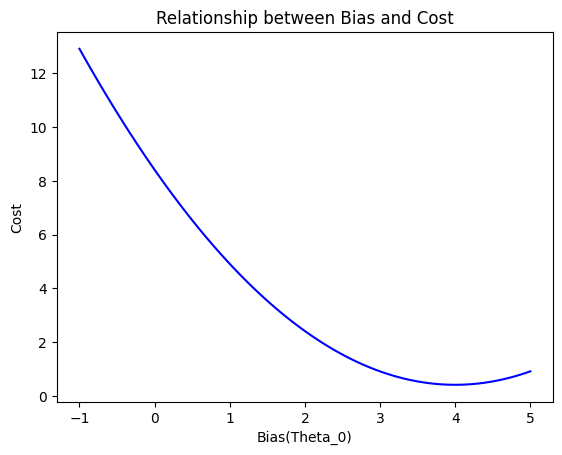

In [8]:
# Create a range to test Bias (theta_0) values
weights_range = np.linspace(-1, 5, 100) # Generate 100 different theta_0 values between -1 and 5

# Calculate the cost function for each bias (theta_0) value
cost_values = [compute_cost(X_b, y, np.array([[w], [3]])) for w in weights_range]# Keeping theta_1 (slope) fixed at 3 while theta_0 varies

# Plotting the graph
plt.plot(weights_range, cost_values, 'b-') # Plot the cost function curve with a blue line
plt.xlabel('Bias(Theta_0)') # X-axis label (theta_0)
plt.ylabel('Cost') # Y-axis label (MSE loss function)
plt.title('Relationship between Bias and Cost') # Plot title
plt.show() # Display the plot

**Neural Networks & Prediction**

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [10]:
input_data = np.array([[0],[1],[2],[3]])
output_data = np.array([0,2,4,6])

In [11]:
model = Sequential([
    Dense(units=1, input_shape=(1,))
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer='sgd',loss='mean_squared_error')

In [13]:
model.fit(input_data, output_data, epochs=1000, verbose=0)

In [14]:
test_data = np.array([[4],[5],[6]])

In [15]:
print("Prediction Result: ",model.predict(test_data))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Prediction Result:  [[ 7.999174]
 [ 9.998732]
 [11.998289]]


**CART - Classification and Regression Trees**

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
import pandas as pd

In [17]:
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['Target'] = iris.target

X = iris.data
y = iris.target


In [18]:
model = DecisionTreeClassifier()
model.fit(X,y)

DecisionTreeClassifier()

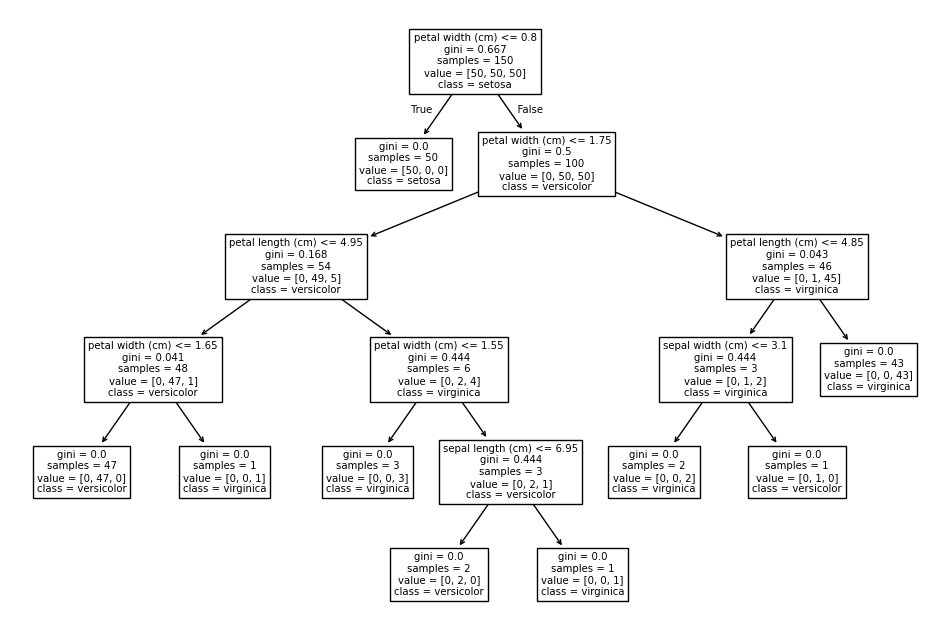

In [19]:
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

**Random Forest**

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4, random_state=42)

In [22]:
model = RandomForestClassifier(n_estimators=100, random_state=34)

In [23]:
model.fit(X_train,y_train)

RandomForestClassifier(random_state=34)

In [24]:
y_pred = model.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: ", accuracy)

Accuracy Score:  0.9833333333333333


**Adaboost**

In [26]:
from sklearn.ensemble import AdaBoostClassifier

In [27]:
model = AdaBoostClassifier(n_estimators=10, random_state=34)

In [28]:
model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=10, random_state=34)

In [29]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: ",accuracy)

Accuracy Score:  0.9833333333333333
